# Analisis SHAP de Resultados - Clasificación

## 1. Importar Librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import h5py
import json
import pickle
import os
import shap

### 1.1 Rutas

In [2]:
class CFG:
    colab = False  # Cambiar a True si se usa Colab
    Root = '..' if not colab else '/content/drive/MyDrive/PAI'
    path_df_imputed = f'{Root}/BaseDatos/df_imputed_with_original.csv'
    path_df_imputed_corrected = f'{Root}/BaseDatos/df_imputed_corrected.csv'
    elements_list = ["Nitrogen", "Phosphorus", "Potassium"]
    productivity_vars = ["Plant_Height (cm)", "Number of Flowers", 'Number of Harvested Fruits', 
                         'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
    model_list = ['RF', 'SVM', 'MLP', 'KNN']
    include_prod = False  # Para incluir variables de productividad


    # NOTE: Cambiar el siguiente flag segun el tipo de entrenamiento
    individual_train = False # Para entrenar con los elementos por separado
    cuartiles_train = True

    # NOTE: Cambiar el siguiente path segun include prod
    if include_prod:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_include_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_include_prod/'
    else:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_exclude_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_exclude_prod/'


    if individual_train:
        path_pkl_results_classification = f"{class_path}class_results_individual_elements.pkl"
    elif cuartiles_train:
        path_pkl_results_classification = f"{class_path}class_models_cuartiles.pkl"
    else:
        path_pkl_results_classification = f"{class_path}all_classification_models.pkl"

    treat_quantiles_path = f'{Root}/Resultados/treatments_quantile_unified.json'

In [3]:
if CFG.colab:
    from google.colab import drive
    drive.mount('/content/drive')

## 2. Funciones

### 2.1 Funciones Comparar Modelos Clasificación

In [4]:
def compare_classification_models(resultados_dict):
    """Compara el rendimiento de diferentes modelos.

    Args:
        resultados_dict (dict):
            Diccionario con resultados de cada modelo
            Formato: {model_name: [lista de resultados por n_clases]}
    """
    def plot_comparative_bars(resultados_dict: dict, metric: str):

        if CFG.individual_train:
            n_classes = CFG.elements_list
        elif CFG.cuartiles_train:
            n_classes = ["Quartiles"]
        else:
            n_classes = np.arange(2, 10)

        fig, ax = plt.subplots(figsize=(10, 6))
        width = 0.1  # the width of the bars
        multiplier = 0
        x = np.arange(len(n_classes))
        for model_name, resultados in resultados_dict.items():
            metrics = [resultados[i][metric] for i in range(len(resultados))]


            offset = width * multiplier
            rects = ax.bar(x + offset, metrics, width, label=model_name)
            #ax.bar_label(rects, padding=8,  fmt='{:.3f}', rotation = 45)

            # Poner Etiquetas
            for rect in rects:
                height = rect.get_height()
                ax.text(rect.get_x() + rect.get_width()/2,  # +0.02 mueve a la derecha
                        height + height*0.01,
                        f'{height:.3f}',
                        ha='left',  # alineación horizontal izquierda
                        va='bottom',  # alineación vertical abajo
                        rotation=90,
                        fontsize=8)

            multiplier += 1

        # Add some text for labels, title and custom x-axis tick labels, etc.
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax.set_title(f'Comparison of Models by {metric.replace("_", " ").title()}', fontsize=14, pad=15)
        ax.set_xticks(x + width, n_classes)
        if CFG.individual_train:
            ax.set_xlabel('Model by element', fontsize=12)
        elif CFG.cuartiles_train:
            ax.set_xlabel('Model', fontsize=12)
        else:
            ax.set_xlabel('Number of Classes', fontsize=12)
        ax.legend()
        ax.set_ylim(0, 1)

        plt.show()

    # Gráficos comparativos
    plot_comparative_bars(resultados_dict, 'accuracy_test')
    plot_comparative_bars(resultados_dict, 'f1_test')
    # Tabla resumen
    print("\n" + "="*80)
    print("SUMMARY OF BEST RESULTS BY MODEL")
    print("="*80)
    for model_name, resultados in resultados_dict.items():
        df_temp = pd.DataFrame(resultados)
        best_idx = df_temp['f1_test'].idxmax()
        best_result = df_temp.iloc[best_idx]
        print(f"\n{model_name}:")
        if CFG.individual_train:
            print(f"  Best element: {best_result['n_clases']}")
        else:
            print(f"  Best n_classes: {best_result['n_clases']}")
        print(f"  Accuracy: {best_result['accuracy_test']:.4f}")
        print(f"  F1 Macro: {best_result['f1_test']:.4f}")

### 2.2 Funciones Analisis SHAP

In [5]:
def load_pickle_results(filepath):
    """Carga resultados desde un archivo pickle.

    Args:
        filepath (str): Ruta al archivo pickle.
    Returns:
        object: Objeto cargado desde el pickle.
    """
    with open(filepath, 'rb') as f:
        results = pickle.load(f)
    return results

def return_top_variables_shap(results):

    """Devuelve las variables más importantes según SHAP.
    Realiza el promedio absoluto de las importancias SHAP para cada variable.
    El promedio lo hace para todos los samples y todas las clases.

    Args:
        results (dict): Diccionario con los resultados del modelo.
    Returns:
        pd.DataFrame: DataFrame con las variables y su importancia SHAP.
    """
    shap_values = results['shap_values']
    X_scaled_df = results['X_scaled_df']

    # Calcular la importancia media absoluta de SHAP para cada característica
    # Handle both 2D (binary) and 3D (multi-class) SHAP arrays
    if len(shap_values.shape) == 2:
        # Binary classification: (n_samples, n_features)
        shap_importance = np.mean(np.abs(shap_values), axis=0)
    else:
        # Multi-class: (n_samples, n_features, n_classes)
        shap_importance = np.mean(np.abs(shap_values), axis=(0, 2))
    
    print(shap_importance.shape)

    # Crear un DataFrame con las características y su importancia
    shap_df = pd.DataFrame({
        'feature': X_scaled_df.columns,
        'shap_importance': shap_importance
    })

    # Ordenar por importancia descendente
    shap_df = shap_df.sort_values(by='shap_importance', ascending=False).reset_index(drop=True)

    return shap_df



def global_shap_N_class(results_model_i, model_name, dir_path = ".") -> pd.DataFrame:
    """Calcula la importancia gloal de SHAP dada una lista de valores shap para una clase específico.
    Se busca hacer promedio absoluto de las importancias SHAP por clase.
    Args:
        results_model_i (list): Lista de resultados del modelo. Internamente se espera que cada elemento tenga 'shap_values' y 'X_scaled_df'.
                                'shap_values' debe tener forma (n_samples, n_features, n_classes) o (n_samples, n_features) para binario.
        model_name (str): Nombre del modelo.
    """
    global_variables =  np.zeros(results_model_i[0]['X_scaled_df'].shape[1]) # se espera que sea 26
    global_df = pd.DataFrame()
    for i in range(len(results_model_i)):
        #print(f"\nTop variables for n_classes = {i+2}:")
        shap_values = results_model_i[i]['shap_values']
        X_scaled_df = results_model_i[i]['X_scaled_df']
        
        # Handle both 2D (binary) and 3D (multi-class) SHAP arrays
        if len(shap_values.shape) == 2:
            # Binary classification: (n_samples, n_features)
            shap_importance = np.mean(np.abs(shap_values), axis=0)
        else:
            # Multi-class: (n_samples, n_features, n_classes)
            shap_importance = np.mean(np.abs(shap_values), axis=(0, 2))
        
        # sumar valores de shap importance
        global_variables += shap_importance
        if CFG.individual_train or CFG.cuartiles_train:
            global_df_temp = pd.DataFrame({
                f'{results_model_i[i]["n_clases"]}': shap_importance
            })
        else:
            global_df_temp = pd.DataFrame({
                f'class_{i+2}': shap_importance
            })
        global_df = pd.concat([global_df, global_df_temp], axis=1)
        #print(shap_importance)
    # poner columna de features en la primera columna
    global_df.insert(0, 'feature', results_model_i[0]['X_scaled_df'].columns)

    model_name = model_name.replace(" ", "_")
    #dir_path = f"../Resultados/classification/{model_name}"

    #save csv
    #global_df.to_csv(f"{dir_path}/global_shap_importance_by_class.csv", index=False)

    top_global_variables = pd.DataFrame({
        'feature': results_model_i[0]['X_scaled_df'].columns,
        'shap_importance': global_variables / (len(results_model_i))
    })
    top_global_variables = top_global_variables.sort_values(by='shap_importance', ascending=False).reset_index(drop=True)
    #top_global_variables.to_csv(f"{dir_path}/top_global_variables_mean.csv", index=False)
    return global_df

def assign_ranking_weights(df, weight_method='percentage'):
    """Asigna ponderaciones según el ranking de importancia SHAP.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'feature' y 'class_{i}'.
        weight_method (str): Método de ponderación:
            - 'linear': 1/posición (ej: 1, 1/2, 1/3, ...)
            - 'exponential': 2^(n-posición) donde n es el total de features
            - 'inverse_square': 1/posición^2
            - 'rank': n - posición + 1 (ej: n, n-1, n-2, ...)
    Returns:
        pd.DataFrame: DataFrame con ponderaciones por clase.
    """
    n_features = len(df)
    if CFG.individual_train:
        class_columns = [col for col in df.columns if col.startswith('3')]
    elif CFG.cuartiles_train:
        class_columns = [col for col in df.columns if col.startswith('2')]
    else:
        class_columns = [col for col in df.columns if col.startswith('class_')]

    # DataFrame para almacenar las ponderaciones
    weights_df = pd.DataFrame()
    weights_df['feature'] = df['feature']
    # display(df)
    for class_col in class_columns:
        # Ordenar por importancia SHAP descendente
        sorted_df = df[['feature', class_col]].sort_values(by=class_col, ascending=False).reset_index(drop=True)

        # Calcular ponderaciones según el método elegido
        if weight_method == 'linear':
            # 1/posición: 1, 1/2, 1/3, ..., 1/n
            weights = 1 / (sorted_df.index + 1)
        elif weight_method == 'exponential':
            # 2^(n-posición): más peso a los primeros
            weights = 2 ** (n_features - sorted_df.index - 1)
        elif weight_method == 'inverse_square':
            # 1/posición^2: decae más rápido
            weights = 1 / ((sorted_df.index + 1) ** 2)
        elif weight_method == 'rank':
            # n - posición + 1: n, n-1, n-2, ..., 1
            weights = n_features - sorted_df.index
        elif weight_method == 'percentage':
            # Obtener porcentage de cada valor shap
            weights = sorted_df[class_col] / sorted_df[class_col].sum()
        else:
            raise ValueError(f"Método '{weight_method}' no reconocido")

        # Crear DataFrame temporal con ponderaciones
        temp_df = pd.DataFrame({
            'feature': sorted_df['feature'],
            f'weight_{class_col}': weights
        })

        # Merge para mantener el orden original de features
        weights_df = weights_df.merge(temp_df, on='feature', how='left')

    return weights_df

def average_models_by_order(results_models_all, dir_path_base, weight_method):
    """
    
    """
    df_sum = None
    for model_name, results_model_i in results_models_all.items():
        dir_path = f"{dir_path_base}/{model_name.replace(' ', '_')}"
        #save shap values for all classes
        global_shap_model_i =  global_shap_N_class(results_model_i, model_name, dir_path)

        # Assign values according the its ranking
        weighted_rf_model_i = assign_ranking_weights(global_shap_model_i, weight_method=weight_method)

        cols = weighted_rf_model_i.columns[1:] # don't include feature column
        if df_sum is None:
            df_sum = weighted_rf_model_i.copy()
        else:
          df_sum[cols] += weighted_rf_model_i[cols] # Acumulate according to the ranking

    df_sum[cols] = df_sum[cols] / len(results_models_all) # Averagin according to the number of models
    return df_sum

def top_variables_by_algorithm(results_models_all, dir_path_base):
    for model_name, results_model_i in results_models_all.items():
        dir_path = f"{dir_path_base}/{model_name.replace(' ', '_')}"
        #save shap values for all classes
        global_shap_model_i =  global_shap_N_class(results_model_i, model_name, dir_path)

        
        for col in global_shap_model_i.columns:
            if col.startswith('class_'):
                # Sort global_shap_model_i by the current class column in descending order
                sorted_features = global_shap_model_i.sort_values(by=col, ascending=False)['feature'].reset_index(drop=True)
                # Add the sorted features as a new column to top_features_by_class DataFrame
                col_idx = global_shap_model_i.columns.get_loc(col)
                # Insert the sorted features right after the current column
                global_shap_model_i.insert(col_idx + 1, f'Feature {col}', sorted_features)
            
        global_shap_model_i.rename(columns={'feature': f'feature - {model_name}'}, inplace=True)
        sub_dir_path = f"{dir_path_base}/top_variables_by_algorithm"
        os.makedirs(sub_dir_path, exist_ok=True)
        global_shap_model_i.to_csv(f"{sub_dir_path}/top_variables_by_model_class_{model_name.replace(' ', '_')}.csv", index=False)
        display(global_shap_model_i)


### 3. Ejemplo para un solo modelo

In [6]:
# # CFG.individual_train = False
# # results_model_i = load_pickle_results("../Resultados_bad_imputation/classification/results_RF.pkl")
# model_name = "Random Forest"
# global_df_rf =global_shap_N_class(results_model_i, model_name, "../Resultados_bad_imputation/classification/Random_Forest")

In [7]:
# global_df_rf

In [8]:
# global_df_rf['class_2'].sort_values(ascending=False)

In [9]:
# sorted_df = global_df_rf[['feature', 'class_2']].sort_values(by='class_2', ascending=False).reset_index(drop=True)
# sorted_df['percentage'] = sorted_df['class_2'] / sorted_df['class_2'].sum() * 100
# sorted_df

In [10]:
# assign_ranking_weights(global_df_rf, weight_method='percentage')

---

# 3. Análisis SHAP Resultados

---

In [11]:
results_models_all = load_pickle_results(CFG.path_pkl_results_classification)

## 3.0.1. Gráficas Modelos Clasificación

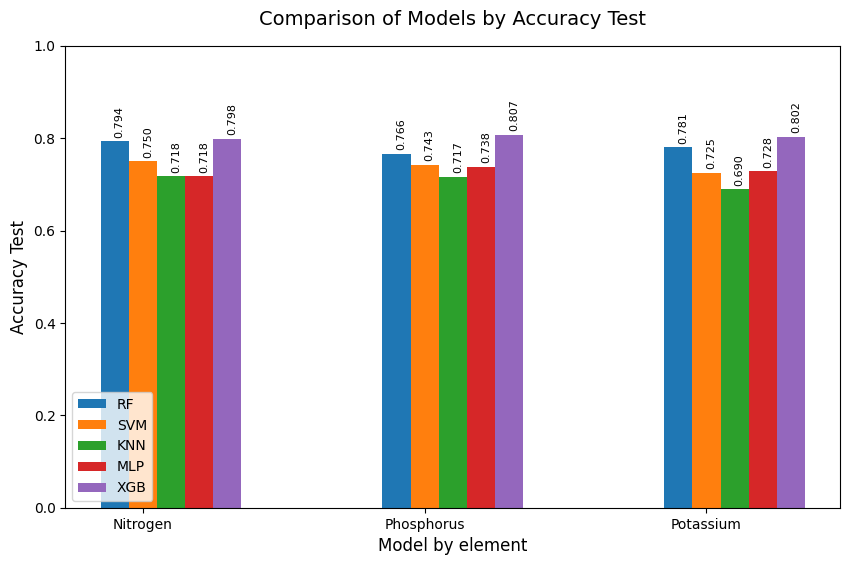

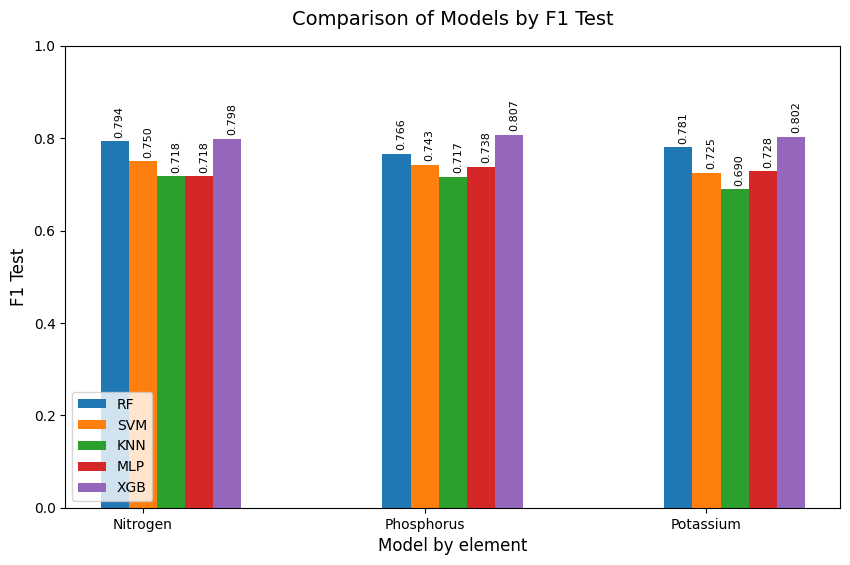


SUMMARY OF BEST RESULTS BY MODEL

RF:
  Best element: 3_Nitrogen
  Accuracy: 0.7936
  F1 Macro: 0.7936

SVM:
  Best element: 3_Nitrogen
  Accuracy: 0.7500
  F1 Macro: 0.7500

KNN:
  Best element: 3_Nitrogen
  Accuracy: 0.7180
  F1 Macro: 0.7180

MLP:
  Best element: 3_Phosphorus
  Accuracy: 0.7384
  F1 Macro: 0.7384

XGB:
  Best element: 3_Phosphorus
  Accuracy: 0.8067
  F1 Macro: 0.8067


In [121]:
compare_classification_models(results_models_all)

## Dependence Plot

## 3.1 Ranking Variables Promedio - Todos los Algoritmos

In [122]:
# for i in range(results_models_all["Random Forest"][7]['shap_values'].shape[2]):
#     print(np.mean(np.abs(results_models_all["Random Forest"][7]['shap_values'][...,i]), axis=0))
# print(np.mean(np.abs(results_models_all["Random Forest"][7]['shap_values'][...,1]), axis=0)-np.mean(np.abs(results_models_all["Random Forest"][7]['shap_values'][...,0]), axis=0))

In [123]:
# np.mean(np.abs(results_models_all["Random Forest"][0]['shap_values']), axis=(0,2))

### **3.1.1 Promedio SHAP de todos los modelos**

In [124]:

# df_sum_avrg = average_models_by_order(results_models_all, CFG.class_path,
#                                       weight_method = 'percentage')
# df_sum_avrg

### **3.1.2 Ordenar SHAP Values**

In [125]:
# for col in df_sum_avrg.columns:
#     if col.startswith('weight_'):
#         print(f"\nTop features for {col} (Average SHAP Importance):")
#         display(df_sum_avrg[['feature', col]].sort_values(by=col, ascending=False).reset_index(drop=True))


### **3.1.2 Obtener Variables Top (En promedio todos los modelos)**

In [126]:
# top_features_by_class = pd.DataFrame({'top': range(1, len(df_sum_avrg) + 1)})

# for col in df_sum_avrg.columns:
#     if col.startswith('weight_'):
#         # Sort df_sum_avrg by the current class column in descending order
#         sorted_features = df_sum_avrg.sort_values(by=col, ascending=False)['feature'].reset_index(drop=True)
#         # Add the sorted features as a new column to top_features_by_class DataFrame
#         top_features_by_class[col] = sorted_features

# display(top_features_by_class)
# top_features_by_class.to_csv(f"{CFG.class_path}top_features_by_class.csv", index=False)

## 3.2. Top Variables - Mejor Algoritmo

In [127]:
print(results_models_all.keys())

dict_keys(['RF', 'SVM', 'KNN', 'MLP', 'XGB'])


### **3.2.1 Acuracy de cada Algoritmo por Clase**

In [128]:
summary_metrics = {'model':[]}
for model, results in results_models_all.items():
    summary_metrics['model'].append(f'acc_test_{model}')
    #summary_metrics['model'].append(f'acc_train_{model}')
    #summary_metrics['model'].append(f'f1_{model}')
    for result in results:
      if result['n_clases'] not in summary_metrics:
        summary_metrics[result['n_clases']] = []
      summary_metrics[result['n_clases']].append(result['accuracy_test'])
      #summary_metrics[result['n_clases']].append(result['accuracy_train'])
      #summary_metrics[result['n_clases']].append(result['f1_macro_test'])
df_summary_metrics = pd.DataFrame(summary_metrics)
df_summary_metrics['avg'] = df_summary_metrics.iloc[:,1:].mean(axis=1)

# Extract the row
best_model_row = df_summary_metrics.loc[df_summary_metrics['avg'].idxmax()]

# Extract the 'model' value from this row
best_model_value = (best_model_row['model']).split('_')[2]

print(f"The model with the highest average performance is: {best_model_value}")


df_summary_metrics


The model with the highest average performance is: XGB


,model,3_Nitrogen,3_Phosphorus,3_Potassium,avg
0,acc_test_RF,0.793605,0.765988,0.780523,0.780039
1,acc_test_SVM,0.750000,0.742733,0.725291,0.739341
2,acc_test_KNN,0.718023,0.716570,0.690407,0.708333
3,acc_test_MLP,0.718023,0.738372,0.728198,0.728198
4,acc_test_XGB,0.797965,0.806686,0.802326,0.802326


### **3.2.2. ¿Cuál fue el Mejor Algoritmo por cada Modelo?**

In [129]:
print('Model with highest metric for each column:')
best_models_class = {} # Save the best models in each class
for col in df_summary_metrics.columns:
    # Convert column name to string before using startswith
    if str(col).startswith(('2', '3', '4', '5', '6', '7', '8', '9')):
        df_filtered = df_summary_metrics[~df_summary_metrics['model'].str.contains('train', case=False, na=False)]
        
        max_value = df_filtered[col].max()
        model_name = df_filtered.loc[df_filtered[col].idxmax(), 'model']
        best_models_class[col] = model_name
        print(f"  Column '{col}': Model = {model_name} (Value = {max_value:.4f})")

Model with highest metric for each column:
  Column '3_Nitrogen': Model = acc_test_XGB (Value = 0.7980)
  Column '3_Phosphorus': Model = acc_test_XGB (Value = 0.8067)
  Column '3_Potassium': Model = acc_test_XGB (Value = 0.8023)


#### 3.2.3 Mejores Variables del Mejor algoritmo por clase

Se organiza las variables con su SHAP value para cada modelo de n clases con su respectivo algoritmo que da el mejor accuracy en esa clase.

In [130]:

# df_best_models_class = pd.DataFrame()
# for col, model_name in best_models_class.items(): # Extraer los mejores modelos por clase
#   model_name = model_name.split("_")[2]
#   temp_results = global_shap_N_class(results_models_all[model_name], model_name)
#   #Agregar columna al df_best_models_class
#   print(model_name, col)
#   display(temp_results)
  
#   if CFG.individual_train:
#     df_best_models_class[f'{col} ({model_name})'] = temp_results[f'{col}'].reset_index(drop=True)
#   else:
#     df_best_models_class[f'class_{col} ({model_name})'] = temp_results[f'class_{col}'].reset_index(drop=True)
#   #display(temp_results[f'class_{col}'].sort_values(ascending=False))
# #poner features a la izquierda
# df_best_models_class.insert(0, 'feature', temp_results['feature'])
# df_best_models_class

### **3.2.3 Ordenar y ubicar la variable correspondiente**

In [131]:
# ranked_df = assign_ranking_weights(df_best_models_class, weight_method='percentage')
# best_features_80_percent = {}
# for col in ranked_df.columns:
#     if col.startswith('weight_'):
#         print(f"\nTop features for {col} (Best Models by Class - Average SHAP Importance):")
#         #obtener el 80% de las features
#         sorted_df = ranked_df[['feature', col]].sort_values(by=col, ascending=False).reset_index(drop=True)
#         sorted_df['acumulated'] = sorted_df[col].cumsum() / sorted_df[col].sum()
#         #display(sorted_df)
#         #recorrer todas las feautres y parar hasta que el acumulado sea el 80%
#         cumulative_sum = 0
#         top_features = []
#         for index, row in sorted_df.iterrows():
#             cumulative_sum += row[col]
#             top_features.append(row['feature'])
#             if cumulative_sum >= 0.8:
#                 break
#         best_features_80_percent[col] = top_features
# print(best_features_80_percent)
# #convert to df  
# df_best_features_80_percent = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in best_features_80_percent.items()]))
# display(df_best_features_80_percent)
# #save csv
# df_best_features_80_percent.to_csv(f"{CFG.class_path}best_features_80_percent_by_class_best_algorithm.csv", index=False)
# #save csv
# ranked_df.to_csv(f"{CFG.class_path}ranked_best_models_by_class.csv", index=False)
# #display(ranked_df)

In [132]:
# df_best_models_class = pd.DataFrame()
# for col, model_name in best_models_class.items():
#   model_name = model_name.split("_")[2]
#   temp_results = global_shap_N_class(results_models_all[model_name], model_name)
#   #Agregar columna al df_best_models_class
#   if CFG.individual_train:
#     df_best_models_class[f'{col} ({model_name})'] = temp_results.sort_values(by=f'{col}', ascending=False)['feature'].reset_index(drop=True)
#   else:
#     df_best_models_class[f'class_{col} ({model_name})'] = temp_results.sort_values(by=f'class_{col}', ascending=False)['feature'].reset_index(drop=True)
#   #display(temp_results[f'class_{col}'].sort_values(ascending=False))


# df_best_models_class.to_csv(F"{CFG.class_path}best_models_top_features_by_class.csv", index=False)
# df_best_models_class

## 3.3 Top Variables - **Por CADA Algoritmo**

### **3.3.1 Ranking SHAP- Ponderar por Porcentaje**

In [133]:
for model_name, results_model_i in results_models_all.items():
    df_top_algorithm = pd.DataFrame()
    dir_path = f"{CFG.class_path}/{model_name.replace(' ', '_')}"
    #save shap values for all classes
    global_shap_model_i =  global_shap_N_class(results_model_i, model_name, dir_path)
    print(model_name)
    #display(global_shap_model_i)
    ranked_df = assign_ranking_weights(global_shap_model_i, weight_method='percentage')
    
    #display(ranked_df)


RF
SVM
KNN
MLP
XGB


### **3.3.2 Top x% Variables de los algoritmos**

Procedimiento:
- Extraer SHAP por cada modelo
    - Promedio de las N clases en cada modelo
- Hacer ranking según el porcentaje
- Ordenar según el valor
- Guardar variables hasta que se supere un porcentaje acumulado
- Repetir por cada algoritmo

In [134]:

def extract_top_x_percent_features(results_models_all, percent=0.8):
    # Variable para guardar las features (será la misma para todos)
    features = None
    best_x_percentage_all_algorithms = {}

    for model_name, results_model_i in results_models_all.items():
        dir_path = f"{CFG.class_path}/{model_name.replace(' ', '_')}"
        # Save shap values for each algorithm
        global_shap_model_i = global_shap_N_class(results_model_i, model_name, dir_path)
        ranked_df = assign_ranking_weights(global_shap_model_i, weight_method='percentage')

        for col in ranked_df.columns:
            if col.startswith('weight_'):
                # Obtener el 80% de las features
                sorted_df = ranked_df[['feature', col]].sort_values(by=col, ascending=False).reset_index(drop=True)
                sorted_df['acumulated'] = sorted_df[col].cumsum() / sorted_df[col].sum()
                display(sorted_df)
                # Recorrer todas las features y parar hasta que el acumulado sea el 80%
                cumulative_sum = 0
                top_features = []
                for index, row in sorted_df.iterrows():
                    cumulative_sum += row[col]
                    top_features.append(row['feature'])
                    if cumulative_sum >= percent:
                        break
                
                # Inicializar la columna si no existe
                if col not in best_x_percentage_all_algorithms:
                    best_x_percentage_all_algorithms[col] = {}
                
                # Guardar las top features para este modelo y columna
                best_x_percentage_all_algorithms[col][f"{col}_{model_name}"] = top_features
                print(f"  {len(top_features)} features que acumulan {cumulative_sum:.2%}")

    # almacenar en csv
    for col, models_dict in best_x_percentage_all_algorithms.items():
        df_temp = pd.DataFrame()
        for model, features_list in models_dict.items():
            df_temp[model] = pd.Series(features_list)
        df_temp.to_csv(f"{CFG.class_path}best_{int(percent*100)}_percent_features_{col}.csv", index=False)
    return best_x_percentage_all_algorithms


In [135]:
extract_top_x_percent_features(results_models_all, percent=0.8)
extract_top_x_percent_features(results_models_all, percent=0.7)
    

,feature,weight_3_Nitrogen,acumulated
0,Chlorophyll (SPAD),0.098308,0.098308
1,Soil NO3 Horiba (ppm),0.076740,0.175049
2,Sap Conductivity (mS/cm),0.065630,0.240679
3,Soil pH Horiba,0.055686,0.296364
4,Sap K (ppm),0.054198,0.350562
5,Sap Na (ppm),0.052459,0.403021
6,Soil Na Horiba (ppm),0.051000,0.454021
7,Number of Flowers,0.049295,0.503316
8,Sap Ca (ppm),0.046158,0.549474
9,Sap NO3 (ppm),0.044460,0.593934


  16 features que acumulan 80.19%


,feature,weight_3_Phosphorus,acumulated
0,Air_sensor_Humidity(%RH),0.090573,0.090573
1,Air_sensor_Temperature(C),0.090270,0.180843
2,Sap NO3 (ppm),0.069254,0.250097
3,Plant_Height (cm),0.064640,0.314737
4,Sap Conductivity (mS/cm),0.058243,0.372980
5,Soil K Horiba (ppm),0.055997,0.428978
6,7in1_S_Temperature(C),0.053170,0.482147
7,Soil Ca Horiba (ppm),0.048646,0.530793
8,Chlorophyll (SPAD),0.047070,0.577863
9,Sap Na (ppm),0.036853,0.614717


  16 features que acumulan 80.48%


,feature,weight_3_Potassium,acumulated
0,Sap Conductivity (mS/cm),0.105442,0.105442
1,Sap K (ppm),0.093054,0.198496
2,Soil pH Horiba,0.082561,0.281057
3,Sap Ca (ppm),0.078307,0.359364
4,Soil K Horiba (ppm),0.072817,0.432181
5,Sap Na (ppm),0.064683,0.496865
6,Sap NO3 (ppm),0.053791,0.550656
7,Air_sensor_Humidity(%RH),0.045739,0.596394
8,Number of Flowers,0.039519,0.635913
9,Air_sensor_Temperature(C),0.035617,0.671530


...

,feature,weight_3_Phosphorus,acumulated
0,Sap NO3 (ppm),0.070298,0.070298
1,Soil K Horiba (ppm),0.067578,0.137876
2,Soil Na Horiba (ppm),0.058048,0.195925
3,Soil Ca Horiba (ppm),0.053790,0.249715
4,Plant_Height (cm),0.050130,0.299844
5,Sap Conductivity (mS/cm),0.049922,0.349767
6,Air_sensor_Humidity(%RH),0.049802,0.399569
7,Air_sensor_Temperature(C),0.047201,0.446770
8,Chlorophyll (SPAD),0.045161,0.491931
9,Soil pH Horiba,0.042834,0.534765


  15 features que acumulan 73.05%


,feature,weight_3_Potassium,acumulated
0,Sap Ca (ppm),0.075888,0.075888
1,Sap Conductivity (mS/cm),0.075835,0.151723
2,Sap K (ppm),0.066183,0.217906
3,Sap Na (ppm),0.059388,0.277293
4,Soil K Horiba (ppm),0.058668,0.335962
5,Soil pH Horiba,0.057319,0.393281
6,Number of Flowers,0.053889,0.447170
7,Chlorophyll (SPAD),0.046344,0.493514
8,Sap NO3 (ppm),0.044719,0.538232
9,7in1_Ph(pH),0.042796,0.581028


  13 features que acumulan 70.07%


{'weight_3_Nitrogen': {'weight_3_Nitrogen_RF': ['Chlorophyll (SPAD)',
   'Soil NO3 Horiba (ppm)',
   'Sap Conductivity (mS/cm)',
   'Soil pH Horiba',
   'Sap K (ppm)',
   'Sap Na (ppm)',
   'Soil Na Horiba (ppm)',
   'Number of Flowers',
   'Sap Ca (ppm)',
   'Sap NO3 (ppm)',
   'Plant_Height (cm)',
   'Soil K Horiba (ppm)',
   '7in1_Ph(pH)'],
  'weight_3_Nitrogen_SVM': ['Soil NO3 Horiba (ppm)',
   'Sap Na (ppm)',
   'Sap Conductivity (mS/cm)',
   'Soil pH Horiba',
   'Sap Ca (ppm)',
   'Plant_Height (cm)',
   'Sap NO3 (ppm)',
   'Number of Flowers',
   'Chlorophyll (SPAD)',
   '7in1_Ph(pH)',
   'Sap pH',
   '7in1_Moisture(%RH)',
   '7in1_S_Temperature(C)',
   'Weight of Harvested Fruits (Kg)'],
  'weight_3_Nitrogen_KNN': ['Sap Na (ppm)',
   'Soil pH Horiba',
   'Sap Conductivity (mS/cm)',
   '7in1_Ph(pH)',
   'Sap Ca (ppm)',
   'Number of Flowers',
   'Sap NO3 (ppm)',
   'Plant_Height (cm)',
   '7in1_Moisture(%RH)',
   'Sap pH',
   'Pynamometer_Radiation(W/m2)',
   'Air_sensor_Humidit

## 3.4 Promedio SHAP - Categoria - Todos los Algoritmos

In [136]:
def category_shap_values(results_model_i):
    """
    Extrae los valores SHAP promedio absoluto por categoria para un modelo específico.
    e.g. Las categorías del modelo de 3 clases son: clase 0, clase 1, clase 2 (deficiencia, adecuado, exceso)
    Para dos clases sería: clase 0, clase 1 (tratamientos en q1, tratamientos en q2)

    Args:
        results_model_i (list): Lista de resultados de un algoritmo específico.
                                Cada elemento es para un modelo con n_clases específico.
                                Debe incluir la matriz 'shap_values' y 'n_clases'.
    Returns:
        dict: Diccionario con los valores SHAP promedio absoluto por categoria.
            e.g {3_Nitrogen: [[],[],[]], 3_Phosphorus: [[],[],[]], 3_Potassium: [[],[],[]]}
    """
    shap_by_class = {}
    # Iterar la lista de reusltados( cada elemento es un modelo o nclase)
    for i in range(len(results_model_i)): 
        shap_values = results_model_i[i]['shap_values']
        shap_mean_per_class = np.mean(np.abs(shap_values), axis=0)  # Promedio absoluto por clase        
        shap_by_class[results_model_i[i]['n_clases']] = shap_mean_per_class
    
    return shap_by_class

def category_algorithm_shap_values(results_models_all):
    """
    Calcula los valores SHAP promedio absoluto por categoria y por algoritmo.
    Args:
        results_models_all (dict): Diccionario con los resultados de todos los modelos.
                                    Formato: {algorithm_name: [lista de resultados por n_clases]}
    Returns:
        dict: Diccionario con los valores SHAP por clase y algoritmo.
              Formato: {model_name: {algorithm_name: shap_values}}
    """
    print("Extrayendo valores SHAP por clase y algoritmo...")
    shap_values_all = {}
    for alg_name, results_model_i in results_models_all.items():
        shap_values_all[alg_name] = category_shap_values(results_model_i)
    shap_value_by_class = {}
    #invertir asociación: las claves ahora son las n_classes, y por dentro va cada algoritmo con shap values correspondientes
    model_names = list(shap_values_all[alg_name].keys())
    for n_class in model_names:
        shap_value_by_class[n_class] = {}
        for alg_name in shap_values_all.keys():
            shap_value_by_class[n_class][alg_name] = shap_values_all[alg_name][n_class]
    return shap_value_by_class

def save_shap_category_algorithm_csv(dict_class_algrtm_shap, 
                                      results_models_all, 
                                      dir_path):
    """
    Almacena los valores SHAP por categoria y algoritmo en archivos CSV.
    Args:
        dict_class_algrtm_shap (dict): Diccionario con los valores SHAP por clase y algoritmo.
                                       Formato: {n_class: {algorithm_name: shap_values}}
        results_models_all (dict): Diccionario con los resultados de todos los modelos.
        dir_path (str): Ruta del directorio donde se guardarán los archivos CSV.
    Returns:
        None
    """
    print("Guardando valores SHAP por categoria y algoritmo...")
    for n_class, dict_alg_shap in dict_class_algrtm_shap.items():
        df_temp = pd.DataFrame()
        for alg_name, shap_values in dict_alg_shap.items():
            # si el modelo es XGB y es binario (cuartiles train)
            # crear una columna por cada categoria
            if alg_name == "XGB" and CFG.cuartiles_train:
                # duplicar la columna por compatibilidad
                shap_values = np.column_stack([shap_values, shap_values])
            #insertar cada columna de shap_values corresponde a una categoria diferente.
            for class_idx in range(shap_values.shape[1]):
                df_temp[f'{alg_name}_category_{class_idx}'] = shap_values[:, class_idx]
        df_temp.insert(0, 'feature', results_models_all[list(results_models_all.keys())[0]][0]['X_scaled_df'].columns)
        df_temp.to_csv(f"{dir_path}/shap_values_category_{n_class}.csv", index=False)

    
def variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
                                                percentage,
                                                results_models_all, dir_path):
    """
    Ordena las variables más importantes según los valores SHAP por categoria y algoritmo.
    Se filtran las variables hasta que el porcentaje acumulado de importancia SHAP
    sea igual al porcentaje dado.

    Args:
        dict_class_algrtm_shap (dict): Diccionario con los valores SHAP por clase y algoritmo.
                                       Formato: {model_name: {algorithm_name: shap_values}}
        percentage (float): Porcentaje acumulado de importancia SHAP para filtrar variables.
        results_models_all (dict): Diccionario con los resultados de todos los modelos.
        dir_path (str): Ruta del directorio donde se guardarán los archivos CSV.
    Returns:
        dict: Diccionario con los rankings de variables por clase y en cada algoritmo.
    """
    
    ranking_vars_class = {}
    for n_class, dict_alg_shap in dict_class_algrtm_shap.items():
        ranking_vars_class[n_class] = {}
        for alg_name, shap_values in dict_alg_shap.items():
            # si el modelo es XGB y es binario (cuartiles train)
            # crear una columna por cada categoria
            if alg_name == "XGB" and CFG.cuartiles_train:
                # duplicar la columna por compatibilidad
                shap_values = np.column_stack([shap_values, shap_values])
            for class_idx in range(shap_values.shape[1]):
                # Obtener el ranking de variables para esta clase
                shap_importance = shap_values[:, class_idx]
                #pasar a porcentaje
                shap_importance_p = shap_importance / np.sum(shap_importance)
                ranked_indices = np.argsort(-shap_importance_p)  # Orden descendente

                print(results_models_all[list(results_models_all.keys())[0]][0]['X_scaled_df'].columns[ranked_indices])
                # Filtrar por porcentaje acumulado
                cumulative_importance = np.cumsum(shap_importance_p[ranked_indices])
                num_features = np.sum(cumulative_importance <= percentage) + 1  # +1 para incluir la característica que cruza el umbral
                ranked_indices = ranked_indices[:num_features]

                # Asignar nombres correspondientes de variables
                ranked_features = results_models_all[list(results_models_all.keys())[0]][0]['X_scaled_df'].columns[ranked_indices]

                if f'class_{class_idx}' not in ranking_vars_class[n_class]:
                    ranking_vars_class[n_class][f'class_{class_idx}'] = {}
                ranking_vars_class[n_class][f'class_{class_idx}'][alg_name] = ranked_features.tolist()
    # crear carpeta si no existe
    name_folder = os.path.join(dir_path, "ranking_variables_by_class_algorithm")
    os.makedirs(name_folder, exist_ok=True)
    # ====================guardar en csv, por clase y por nombre de modelo ====================
    print(f"Guardando rankings de variables por clase y algoritmo en {name_folder}") 
    for n_class, dict_alg_rankings in ranking_vars_class.items():
        for class_name, dict_model_rankings in dict_alg_rankings.items():
            df_temp = pd.DataFrame()
            for alg_name, ranked_features in dict_model_rankings.items():
                df_temp[alg_name] = pd.Series(ranked_features)
            df_temp.to_csv(f"{name_folder}/ranking_vars_nclass_{n_class}_{class_name}_{int(percentage*100)}.csv", index=False)
    return ranking_vars_class

def analyze_variable_df(df):
    """
    Analiza las variables más frecuentes en el top N de diferentes modelos.
    
    Args:
        df (pd.DataFrame): DataFrame donde cada columna representa un modelo/clase
                           y cada fila representa una variable en orden de importancia.
            Formato esperado:
            Model1, Model2, Model3, ...
            var1,   var2,   var3, ...
            var4,   var5,   var6, ...
    
    Returns:
        tuple: (DataFrame con frecuencias, DataFrame con posiciones y frecuencias)
    
    """
     # Diccionario para almacenar la frecuencia de cada variable
    variable_frequency = {}
    # Diccionario para almacenar las posiciones de cada variable
    variable_positions = {}
    
    # Iterar sobre cada columna (cada modelo/clase)
    for col in df.columns:
        # Obtener las top N variables de esta columna
        top_vars = df[col].tolist()
        
        # Contar frecuencia y registrar posiciones
        for position, var in enumerate(top_vars, start=1):
            if var not in variable_frequency:
                variable_frequency[var] = 0
                variable_positions[var] = []
            
            variable_frequency[var] += 1
            variable_positions[var].append({
                'model_class': col,
                'position': position
            })
    
    # Crear DataFrame con frecuencias
    freq_df = pd.DataFrame(list(variable_frequency.items()), 
                          columns=['Variable', 'Frequency'])
    freq_df = freq_df.sort_values('Frequency', ascending=False).reset_index(drop=True)
    # Crear DataFrame con posiciones detalladas
    position_data = []
    for var, positions in variable_positions.items():
        for pos_info in positions:
            position_data.append({
                'Variable': var,
                'Model_Class': pos_info['model_class'],
                'Position': pos_info['position'],
                'Frequency': variable_frequency[var]
            })
    
    position_df = pd.DataFrame(position_data)
    
    return freq_df, position_df

def save_top_variable_by_category(ranking_vars_class, percentage, dir_path):
    """
    Guarda las mejores variables por categoría de cada modelo, ponderando
    las variables presentes en todos los algoritmos. Se toma hasta que el porcentaje
    acumulado de importancia SHAP sea igual al porcentaje dado.

    Args:
        ranking_vars_class (dict): Diccionario con los rankings de variables por clase y en 
                                    cada algoritmo.
        percentage (float): Porcentaje acumulado de importancia SHAP para filtrar variables.
        dir_path (str): Ruta del directorio donde se guardarán los archivos CSV.
    Returns:
        None
    """
    print("Guardando top variables por clase y algoritmo...")
    name_folder = os.path.join(dir_path, "ranking_variables_by_class_algorithm")
    os.makedirs(name_folder, exist_ok=True)
    for n_class, dict_alg_rankings in ranking_vars_class.items():
        best_variables_by_class_alg = {}
        for class_name, dict_model_rankings in dict_alg_rankings.items():
            df_temp = pd.DataFrame()
            for alg_name, ranked_features in dict_model_rankings.items():
                df_temp[alg_name] = pd.Series(ranked_features)
            print(f"{class_name} - n_class {n_class}")
            #display(df_temp)
            top_vars_freq, top_vars_positions = analyze_variable_df(df_temp)

            #-------------------------------------
            ## Sumar posiciones para cada variable
            position_summary = top_vars_positions.groupby('Variable', as_index=False).agg({
                'Position': 'sum',
                'Frequency': 'first'  # o 'max' ya que todos tienen el mismo valor
            }).rename(columns={'Position': 'Position_Sum'})

            # Ordenar por Frequency y Position_Sum
            position_summary = position_summary.sort_values(
                        by=['Frequency', 'Position_Sum'], 
                        ascending=[False, True]  
                        ).reset_index(drop=True)
            #display(position_summary)
            #display(analyze_variable_df(df_temp))#.to_csv(f"{name_folder}/variable_frequency_nclass_{n_class}_{class_name}.csv", index=False)
            best_variables_by_class_alg[class_name] = position_summary['Variable'].tolist()
        # guardar mejores variables por clase en todos los algoritmos
        df_best_vars = pd.DataFrame()
        for class_name, var_list in best_variables_by_class_alg.items():
            df_best_vars[class_name] = pd.Series(var_list)
        df_best_vars.to_csv(f"{name_folder}/ponderated_{int(percentage*100)}_best_vars_nclass_{n_class}_all_algorithms.csv", index=False)



In [137]:
dict_class_algrtm_shap = category_algorithm_shap_values(results_models_all)
save_shap_category_algorithm_csv(dict_class_algrtm_shap, results_models_all, CFG.class_path)

Extrayendo valores SHAP por clase y algoritmo...
Guardando valores SHAP por categoria y algoritmo...


#### Guardar variables al 80% - Por Categoría / cada modelo / todos los algoritmos

In [138]:
ranking_vars_class = variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
                                                                 percentage=0.8, 
                                                                 results_models_all=results_models_all, 
                                                                 dir_path=CFG.class_path)
save_top_variable_by_category(ranking_vars_class,
                            percentage=0.8,
                            dir_path=CFG.class_path)

Index(['Chlorophyll (SPAD)', 'Soil NO3 Horiba (ppm)',
       'Sap Conductivity (mS/cm)', 'Soil pH Horiba', 'Soil Na Horiba (ppm)',
       'Sap Na (ppm)', 'Number of Flowers', 'Sap K (ppm)', 'Sap NO3 (ppm)',
       'Sap Ca (ppm)', 'Sap pH', 'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)',
       'Soil Conductivity Horiba (mS/cm)', '7in1_S_Temperature(C)',
       'Plant_Height (cm)', 'Air_sensor_Temperature(C)',
       'Air_sensor_Humidity(%RH)', '7in1_Moisture(%RH)', '7in1_Ph(pH)',
       '7in1_Conductivity(mS/cm)', 'Pynamometer_Radiation(W/m2)',
       'Weight of Harvested Fruits (Kg)', 'Fruit Height (mm)',
       'Fruit Diameter (mm)', 'Number of Harvested Fruits'],
      dtype='object')
Index(['Chlorophyll (SPAD)', 'Sap K (ppm)', 'Sap Na (ppm)',
       'Soil NO3 Horiba (ppm)', 'Sap Ca (ppm)', 'Sap Conductivity (mS/cm)',
       'Soil Na Horiba (ppm)', 'Number of Flowers', 'Plant_Height (cm)',
       'Sap NO3 (ppm)', 'Soil pH Horiba', '7in1_Ph(pH)',
       'Soil Ca Horiba (ppm)', 'Air_se

#### Guardar Variables al 70% - Por Categoría / cada modelo / todos los algoritmos

In [139]:
ranking_vars_class = variable_importance_category_algorithm_shap(dict_class_algrtm_shap,
                                                                 percentage=0.7, 
                                                                 results_models_all=results_models_all, 
                                                                 dir_path=CFG.class_path)
save_top_variable_by_category(ranking_vars_class,
                            percentage=0.7,
                            dir_path=CFG.class_path)

Index(['Chlorophyll (SPAD)', 'Soil NO3 Horiba (ppm)',
       'Sap Conductivity (mS/cm)', 'Soil pH Horiba', 'Soil Na Horiba (ppm)',
       'Sap Na (ppm)', 'Number of Flowers', 'Sap K (ppm)', 'Sap NO3 (ppm)',
       'Sap Ca (ppm)', 'Sap pH', 'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)',
       'Soil Conductivity Horiba (mS/cm)', '7in1_S_Temperature(C)',
       'Plant_Height (cm)', 'Air_sensor_Temperature(C)',
       'Air_sensor_Humidity(%RH)', '7in1_Moisture(%RH)', '7in1_Ph(pH)',
       '7in1_Conductivity(mS/cm)', 'Pynamometer_Radiation(W/m2)',
       'Weight of Harvested Fruits (Kg)', 'Fruit Height (mm)',
       'Fruit Diameter (mm)', 'Number of Harvested Fruits'],
      dtype='object')
Index(['Chlorophyll (SPAD)', 'Sap K (ppm)', 'Sap Na (ppm)',
       'Soil NO3 Horiba (ppm)', 'Sap Ca (ppm)', 'Sap Conductivity (mS/cm)',
       'Soil Na Horiba (ppm)', 'Number of Flowers', 'Plant_Height (cm)',
       'Sap NO3 (ppm)', 'Soil pH Horiba', '7in1_Ph(pH)',
       'Soil Ca Horiba (ppm)', 'Air_se

### 3.3.3. Ranking Variables - All Models - All Algorithms

In [140]:
# # Convertir el diccionario a DataFrame
# # Cada columna del DataFrame representará una columna/clase, y habrá sub-columnas para cada algoritmo

# best_80_all_algorithms = extract_top_x_percent_features(results_models_all, percent=0.8)
# # Opción 1: DataFrame con MultiIndex en columnas
# all_dfs = []
# for col_name, models_dict in best_80_all_algorithms.items():
#     # Crear DataFrame temporal para esta columna
#     temp_df = pd.DataFrame(dict([(model, pd.Series(features)) for model, features in models_dict.items()]))
#     # Agregar nivel de columna con el nombre de la clase
#     temp_df.columns = pd.MultiIndex.from_product([[col_name], temp_df.columns])
#     all_dfs.append(temp_df)

# # Concatenar todos los DataFrames
# df_top_80_by_algorithm = pd.concat(all_dfs, axis=1)
# print("\nDataFrame con top 80% features por columna y algoritmo:")
# display(df_top_80_by_algorithm)

# # Guardar CSV
# output_path = f"{CFG.class_path}/top_80_percent_by_algorithm_and_class.csv"
# df_top_80_by_algorithm.to_csv(output_path, index=False)
# print(f"\nGuardado en: {output_path}")

### 3.3.4. Ranking Todas las variables - Por cada Algoritmo

Obtener ranking de todas las variables (desactivado por el momento)

In [141]:
# # Crear diccionarios para cada elemento
# df_by_element = {
#     'Nitrogen': pd.DataFrame(),
#     'Phosphorus': pd.DataFrame(),
#     'Potassium': pd.DataFrame()
# }

# # Variable para guardar las features (será la misma para todos)
# features = None

# for model_name, results_model_i in results_models_all.items():
#     dir_path = f"{CFG.class_path}/{model_name.replace(' ', '_')}"
#     # Save shap values for all classes
#     global_shap_model_i = global_shap_N_class(results_model_i, model_name, dir_path)
#     ranked_df = assign_ranking_weights(global_shap_model_i, weight_method='percentage')
    
#     # Guardar features solo una vez
#     if features is None:
#         features = ranked_df['feature']
    
#     # Iterar sobre las columnas y asignar a los dataframes correspondientes
#     for col in ranked_df.columns:
#         if str(col).startswith('weight_'):
#             # Ordenar por el peso y obtener las features ordenadas
#             sorted_features = ranked_df.sort_values(by=col, ascending=False)['feature'].reset_index(drop=True)
            
#             if CFG.individual_train:
#                 # Determinar a qué elemento pertenece esta columna
#                 if 'Nitrogen' in col:
#                     df_by_element['Nitrogen'][f'{col} ({model_name})'] = sorted_features
#                 elif 'Phosphorus' in col:
#                     df_by_element['Phosphorus'][f'{col} ({model_name})'] = sorted_features
#                 elif 'Potassium' in col:
#                     df_by_element['Potassium'][f'{col} ({model_name})'] = sorted_features

# # Mostrar y guardar cada dataframe
# for element, df in df_by_element.items():
#     if not df.empty:
#         print(f"\n{'='*60}")
#         print(f"Top variables para {element} - Todos los algoritmos")
#         print(f"{'='*60}")
#         display(df)
        
#         # Guardar CSV
#         output_path = f"{CFG.class_path}/top_variables_by_algorithm"
#         os.makedirs(output_path, exist_ok=True)
#         df.to_csv(f"{output_path}/top_variables_{element}_all_algorithms.csv", index=False)
#         print(f"Guardado en: {output_path}/top_variables_{element}_all_algorithms.csv")

## 4.0 Distribución Variables (3 Modelos Individuales - 3 Clases)

In [142]:
# from ipywidgets import interact, Dropdown, Output
# import ipywidgets as widgets

# # Class descriptions dictionary
# class_descriptions = {
#     "3_Nitrogen": {0: "No Adequate", 1: "Adequate", 2: "Excess"},
#     "3_Phosphorus": {0: "No Adequate", 1: "Adequate", 2: "Excess"},
#     "3_Potassium": {0: "No Adequate", 1: "Adequate", 2: "Excess"},
# }

# # Create widgets
# model_name_widget = widgets.Dropdown(
#     options=['RF', 'SVM', 'KNN', 'MLP'],
#     value='RF',
#     description='Model:',
#     disabled=False,
# )

# element_widget = widgets.Dropdown(
#     options=['3_Nitrogen', '3_Phosphorus', '3_Potassium'],
#     value='3_Nitrogen',
#     description='Element:',
#     disabled=False,
# )

# class_indices_widget = widgets.Dropdown(
#     options=[(f"Class {i}: {class_descriptions['3_Nitrogen'][i]}", i) for i in range(3)],
#     value=0,
#     description='Class Index:',
#     disabled=False,
# )

# output = Output()

# def update_class_indices(*args):
#     """Update class indices options when element changes"""
#     element = element_widget.value
#     class_indices_widget.options = [
#         (f"Class {i}: {class_descriptions[element][i]}", i) 
#         for i in range(3)
#     ]
#     class_indices_widget.value = 0

# # Update class indices when element changes
# element_widget.observe(update_class_indices, 'value')

# def plot_shap_summary(model_name, element, class_index):
#     """Plot SHAP summary for selected model and class"""
#     with output:
#         output.clear_output(wait=True)
        
#         # Get the index for the element (0: Nitrogen, 1: Phosphorus, 2: Potassium)
#         element_idx = ['3_Nitrogen', '3_Phosphorus', '3_Potassium'].index(element)
        
#         # Filter data
#         shap_values = results_models_all[model_name][element_idx]['shap_values']
#         X_scaled_df = results_models_all[model_name][element_idx]['X_scaled_df']
        
#         # Display information
#         print(f"Model: {model_name}")
#         print(f"Element: {element}")
#         print(f"Class {class_index}: {class_descriptions[element][class_index]}")
#         print(f"\nSHAP Summary Plot:")
        
#         # Create SHAP plot
#         shap.summary_plot(shap_values[..., class_index], X_scaled_df, plot_type="dot")

# # Create interactive interface
# interact(plot_shap_summary, 
#          model_name=model_name_widget,
#          element=element_widget, 
#          class_index=class_indices_widget)

# # Display output
# display(output)

## 4. Distribución de Variables (2-9 Numero de Clases)

In [143]:
# from ipywidgets import interact, Dropdown, Output
# import ipywidgets as widgets

# # Class descriptions dictionary
# class_descriptions = {
#     2: {0: "None or only one nutrient adequate", 1: "At least two nutrients adequate"},
#     3: {0: "None adequate", 1: "Only one nutrient adequate", 2: "Two or more nutrients adequate"},
#     4: {0: "None adequate", 1: "Only one adequate", 2: "Two adequate", 3: "Three adequate (NPK)"},
#     5: {0: "None adequate", 1: "Only one adequate", 2: "N and P", 3: "N and K", 4: "All adequate (NPK)"},
#     6: {0: "None adequate", 1: "Only N", 2: "Only P or only K", 3: "N and P or N and K", 4: "P and K", 5: "All adequate (NPK)"},
#     7: {0: "None adequate", 1: "Only N", 2: "Only P", 3: "Only K", 4: "N and P", 5: "N and K / P and K", 6: "All adequate (NPK)"},
#     8: {0: "None adequate", 1: "Only N", 2: "Only P", 3: "Only K", 4: "N and P", 5: "N and K", 6: "P and K", 7: "All adequate"},
#     9: {0: "None adequate", 1: "Only K", 2: "K in excess", 3: "Only N", 4: "Both adequate (NK)", 5: "N adequate, K in excess", 6: "N in excess", 7: "N in excess, K adequate", 8: "Both excess (NK)"}
# }

# # Create widgets
# model_name_widget = widgets.Dropdown(
#     options=['Random Forest', 'SVM', 'KNN', 'MLP'],
#     value='Random Forest',
#     description='Model:',
#     disabled=False,
# )

# model_n_class_widget = widgets.Dropdown(
#     options=list(range(2, 10)),
#     value=4,
#     description='N Classes:',
#     disabled=False,
# )

# class_indices_widget = widgets.Dropdown(
#     options=[(f"Class {i}: {class_descriptions[4][i]}", i) for i in range(4)],
#     value=0,
#     description='Class Index:',
#     disabled=False,
# )

# output = Output()

# def update_class_indices(*args):
#     """Update class indices options when model_n_class changes"""
#     n_class = model_n_class_widget.value
#     class_indices_widget.options = [
#         (f"Class {i}: {class_descriptions[n_class][i]}", i) 
#         for i in range(n_class)
#     ]
#     class_indices_widget.value = 0

# # Update class indices when model_n_class changes
# model_n_class_widget.observe(update_class_indices, 'value')

# def plot_shap_summary(model_name, model_n_class, class_index):
#     """Plot SHAP summary for selected model and class"""
#     with output:
#         output.clear_output(wait=True)
        
#         # Filter data
#         shap_values = results_models_all[model_name][model_n_class - 2]['shap_values']
#         X_scaled_df = results_models_all[model_name][model_n_class - 2]['X_scaled_df']
        
#         # Display information
#         print(f"Model: {model_name}")
#         print(f"Number of classes: {model_n_class}")
#         print(f"Class {class_index}: {class_descriptions[model_n_class][class_index]}")
#         print(f"\nSHAP Summary Plot:")
        
#         # Create SHAP plot
#         shap.summary_plot(shap_values[..., class_index], X_scaled_df, plot_type="dot")

# # Create interactive interface
# interact(plot_shap_summary, 
#          model_name=model_name_widget,
#          model_n_class=model_n_class_widget, 
#          class_index=class_indices_widget)

# # Display output
# display(output)